**Nikhil Sunder**  
ICSRI Research Fellow, University of Miami | Open-Source Developer  
Herbert Business School, University of Miami  
B.S.B.A. Quantitative Economics & Finance; Minor in Mathematics  

**Correspondence:** nss106@miami.edu  
**Research profiles:** [GitHub](https://github.com/nikhilxsunder) · [ORCID](https://orcid.org/0009-0007-3323-1760) · [LinkedIn](https://www.linkedin.com/in/nikhil-sunder/) · [Zenodo](https://zenodo.org/search?q=metadata.creators.person_or_org.name:%22Sunder,+Nikhil%22)  
**Software:** [PyPI](https://pypi.org/user/nikhil.sunder/) · [Anaconda](https://anaconda.org/nikhil.sunder/)

# 10. Reinforcement learning: tabular Q-learning

Watkins's Q-learning on a discretised state and action grid, in each of the four economies.

**Inputs:** the artifacts of notebooks `00` to `07`. **Outputs:** `artifacts/rl/qlearning/*.pt`.

In [1]:
import pandas as pd

import autofed as af
from autofed import plots, rl

nb = af.NotebookSession(
    "10_rl_qlearning", number=10, title="Reinforcement learning: tabular Q-learning"
)

lab = rl.PolicyLab.load(
    nb.workspace.artifacts
)  # economies of notebooks 01-06, settings of notebook 07
cfg = lab.config
OBS_SPECS = ["x1", "x2"]
LOSS_COLUMNS = {
    "dev2 pi": r"$\Delta^2(\pi^*, \pi_t)$",
    "dev2 y": r"$\Delta^2(y^*, y_t)$",
    "dev2 di": r"$\Delta^2(\Delta i_t)$",
}
PATH_NOTE = (
    "Simulated from the first two estimation-window quarters under freshly drawn shocks; every"
    " policy faces the same shocks within an economy. Not a historical counterfactual."
)


def slug(name: str) -> str:
    return name.lower().replace("-", "_").replace(" ", "_")


print(
    "Economies:",
    ", ".join(lab.env_names),
    "| frames per run:",
    cfg.total_timesteps,
    "| seed:",
    cfg.seed,
)

Economies: SVAR, TVP-SVAR-SV, NARX, NSSM | frames per run: 12500 | seed: 2026


## The algorithm

TorchRL ships deep Q-learning (`DQNLoss`) but no tabular agent, and a table is the point of this
section: Wang et al. (2026) report that on similar single-CB monetary MDPs tabular Q-learning
outperforms DQN and Bayesian variants. We implement Watkins's (1989) algorithm directly on a PyTorch
tensor. The state space is discretised to a 6 x 7 grid over $(y, \pi)$ and the action grid is 21 points
in $[0, 10]$, so the table is small enough to train quickly. We restrict to the no-lag observation
specification $x_t^{(1)}$ throughout. The agent interacts with the same TorchRL environment as DDPG and
SAC, stepping it with `step_and_maybe_reset`.

Trained and saved 4 Q-learning cells to artifacts/rl/qlearning


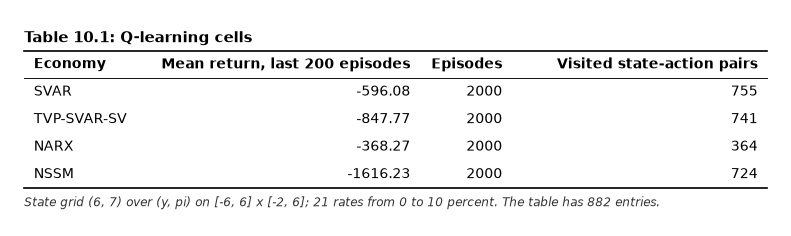

In [2]:
cells = [rl.train_q_cell(lab, env_name) for env_name in lab.env_names]
saved = rl.save_cells(cells, nb.artifacts("rl", "qlearning"))
print(
    f"Trained and saved {len(saved)} Q-learning cells to"
    f" {saved[0].parent.relative_to(nb.workspace.root)}"
)

policy = cells[0].policy
trained = pd.DataFrame({
    c.env_name: {
        "Mean return, last 200 episodes": c.steady_state_reward,
        "Episodes": len(c.training_rewards),
        "Visited state-action pairs": int((c.policy.Q != 0).sum()),
    }
    for c in cells
}).T.astype({"Episodes": int, "Visited state-action pairs": int})
trained.index.name = "Economy"
nb.table(
    trained,
    "trained_cells",
    "Q-learning cells",
    float_format="{:.2f}",
    note=(
        f"State grid {tuple(policy.bins.tolist())} over (y, pi) on [{policy.obs_low[0]:g},"
        f" {policy.obs_high[0]:g}] x [{policy.obs_low[1]:g}, {policy.obs_high[1]:g}];"
        f" {policy.action_grid.numel()} rates from {policy.action_grid[0]:g} to"
        f" {policy.action_grid[-1]:g} percent. The table has {policy.Q.numel()} entries."
    ),
)

## Effective Taylor coefficients

Q-learning's discretised policy is non-linear and non-differentiable; the OLS $R^2$ measures how well a
Taylor-rule form fits the discretised reaction function over the grid.

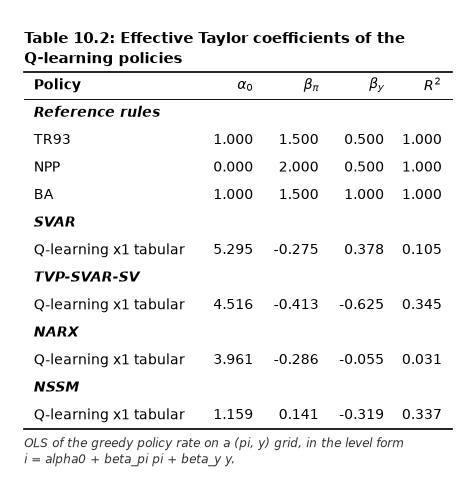

In [3]:
nb.table(
    rl.coefficient_table(cells),
    "taylor_coefficients",
    "Effective Taylor coefficients of the Q-learning policies",
    note=(
        "OLS of the greedy policy rate on a (pi, y) grid, in the level form i = alpha0 +"
        " beta_pi pi + beta_y y."
    ),
)

## Training curves, reaction functions and simulated paths

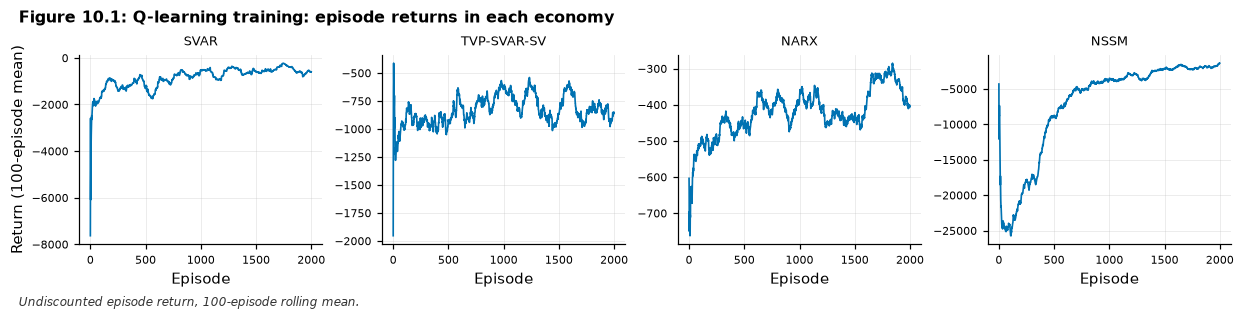

In [4]:
fig = plots.training_curves({c.env_name: c.training_rewards for c in cells}, window=100)
nb.figure(
    fig,
    "training_curves",
    "Q-learning training: episode returns in each economy",
    note="Undiscounted episode return, 100-episode rolling mean.",
)

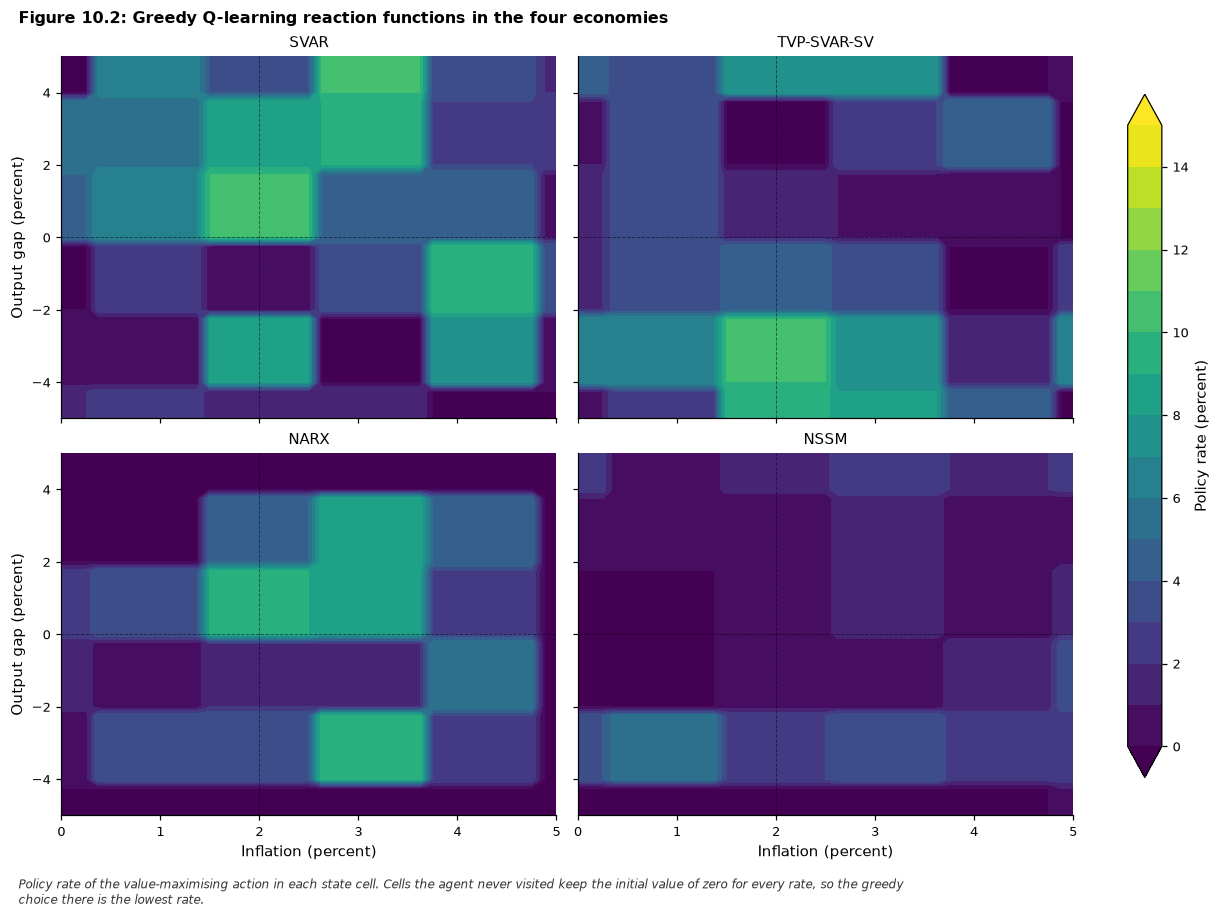

In [5]:
fig = plots.policy_surface_grid(
    {c.env_name: rl.policy_surface(c) for c in cells},
    rate_max=cfg.action_high,
    pi_star=cfg.pi_star,
)
nb.figure(
    fig,
    "reaction_functions",
    "Greedy Q-learning reaction functions in the four economies",
    note=(
        "Policy rate of the value-maximising action in each state cell. Cells the agent never"
        " visited keep the initial value of zero for every rate, so the greedy choice there is"
        " the lowest rate."
    ),
)

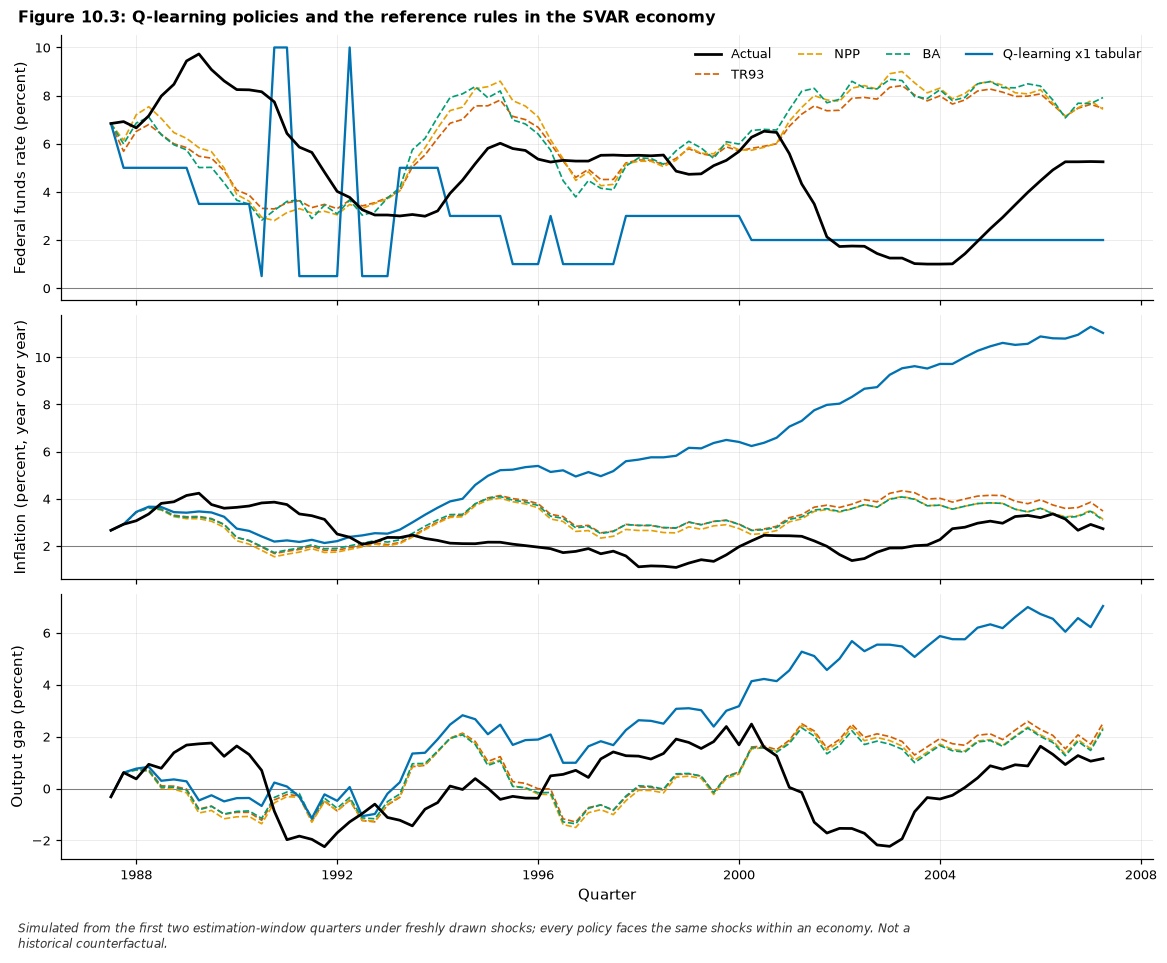

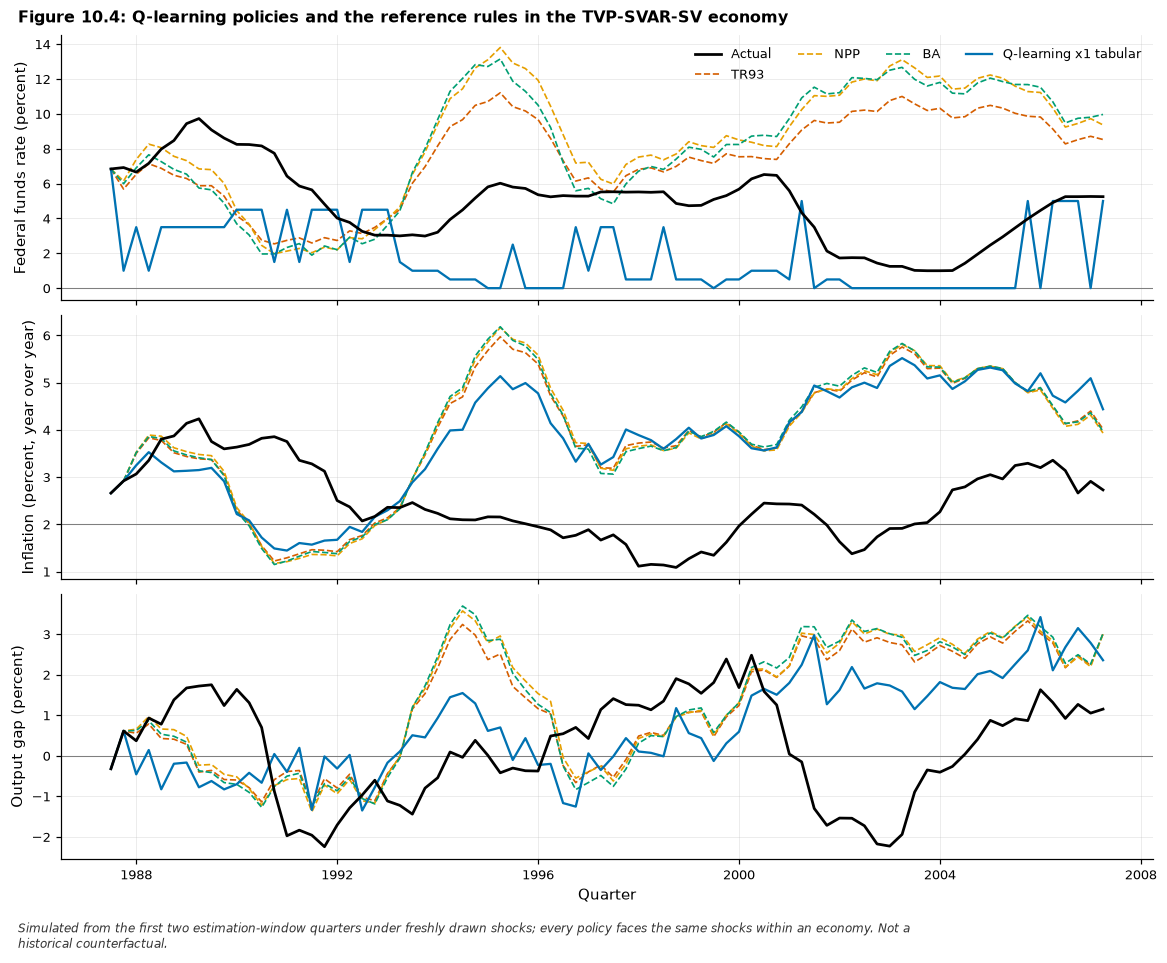

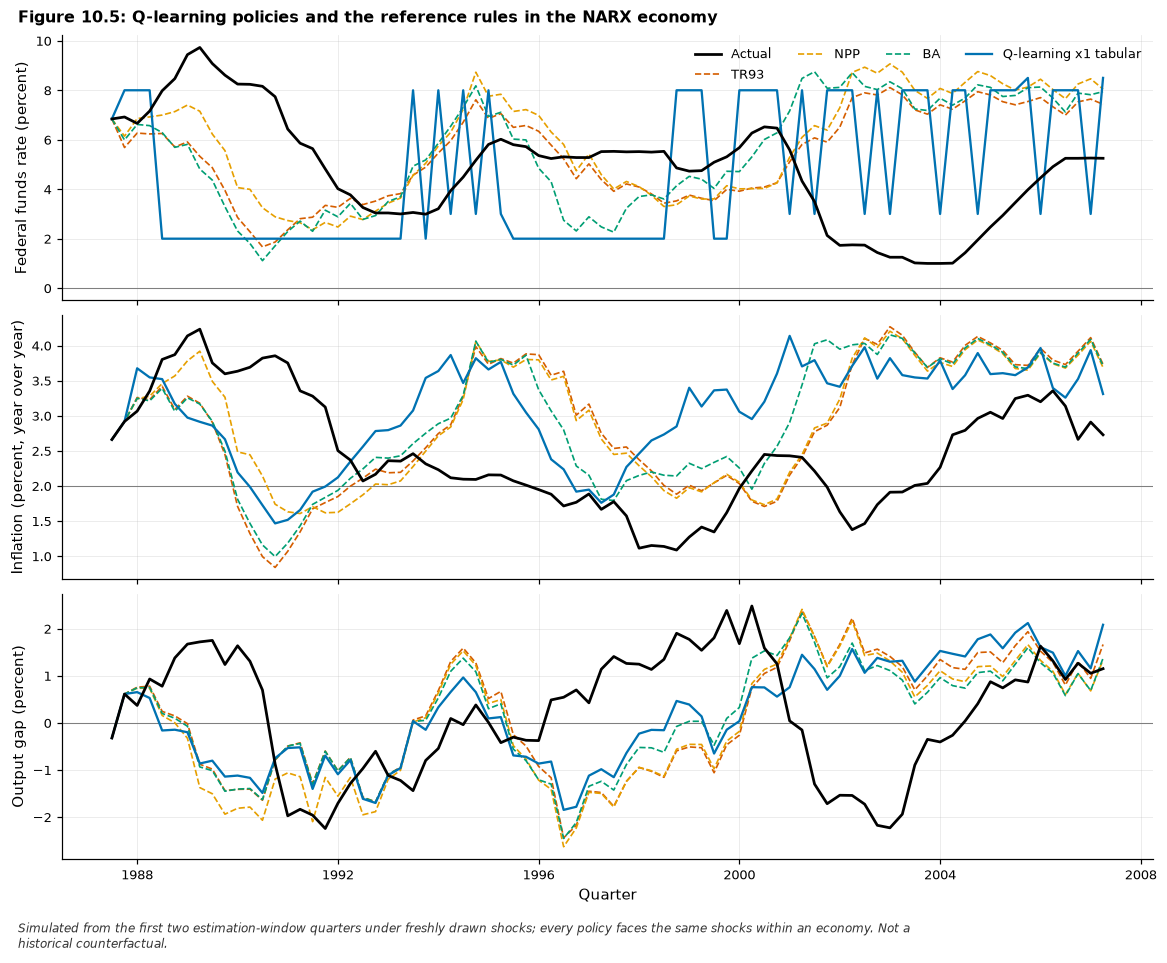

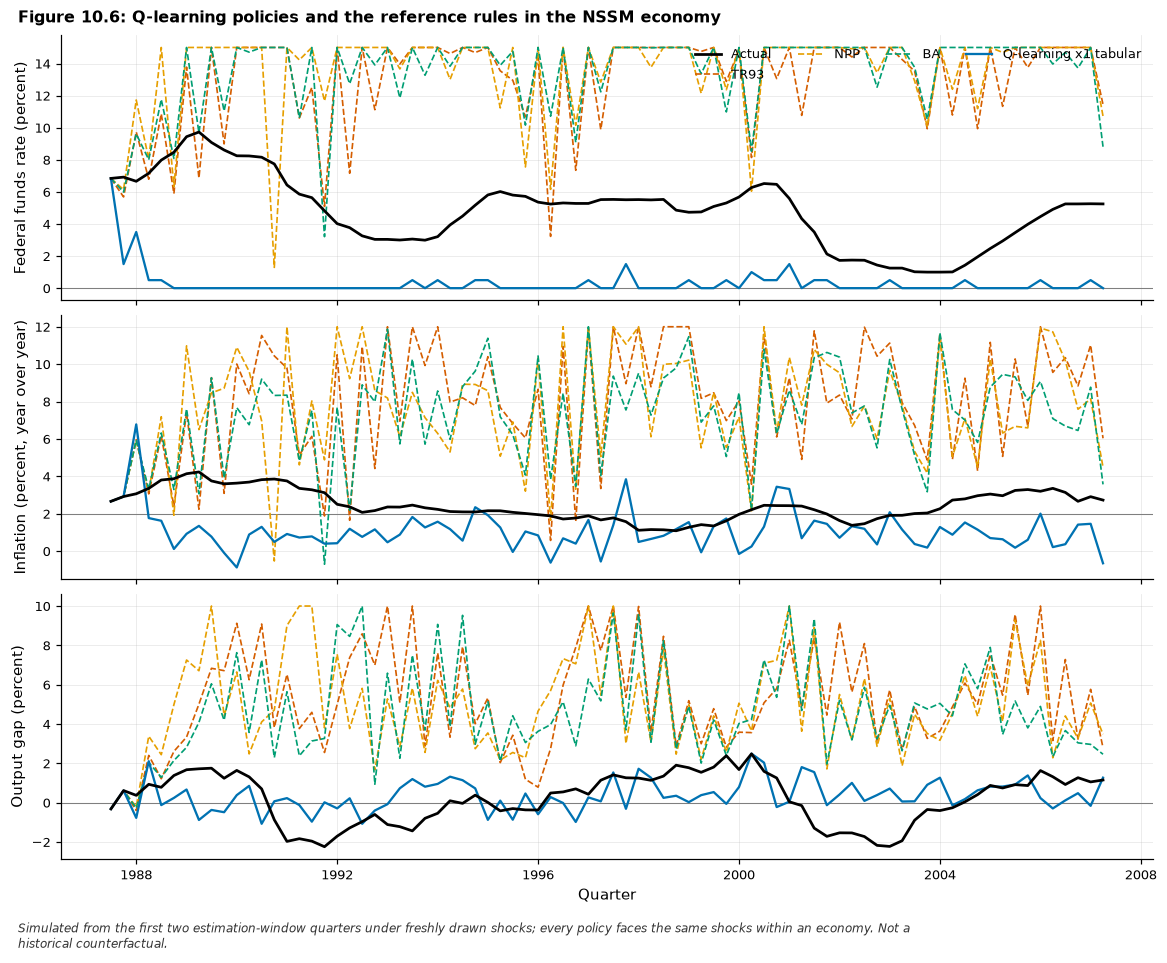

In [6]:
paths_by_economy = {
    env_name: lab.simulate_policies(env_name, cells) for env_name in lab.env_names
}
for env_name, paths in paths_by_economy.items():
    fig = plots.policy_paths(paths, pi_star=cfg.pi_star)
    nb.figure(
        fig,
        f"simulated_paths_{slug(env_name)}",
        f"Q-learning policies and the reference rules in the {env_name} economy",
        note=PATH_NOTE,
    )

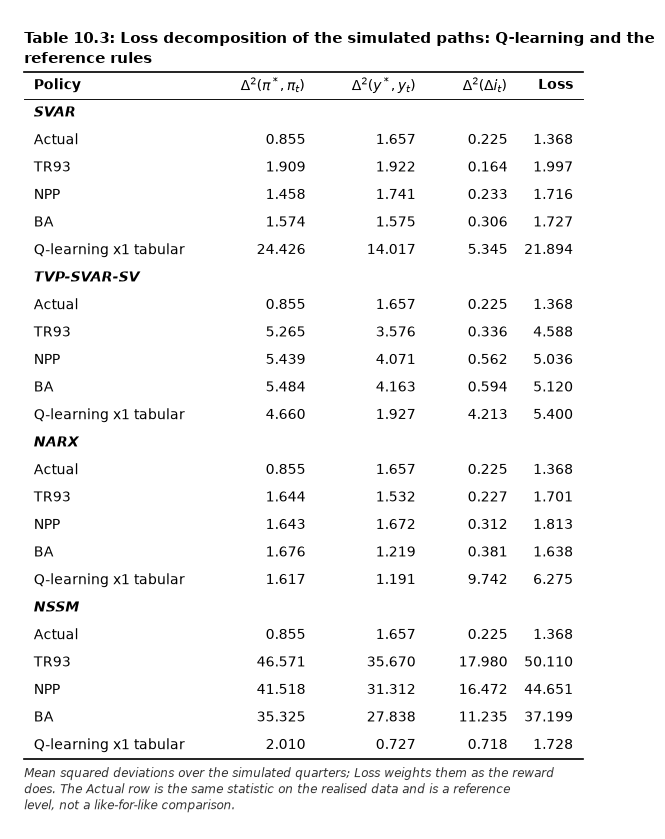

In [7]:
loss_table = lab.loss_table(paths_by_economy).rename(columns=LOSS_COLUMNS)
nb.table(
    loss_table,
    "loss_decomposition",
    "Loss decomposition of the simulated paths: Q-learning and the reference rules",
    note=(
        "Mean squared deviations over the simulated quarters; Loss weights them as the reward"
        " does. The Actual row is the same statistic on the realised data and is a reference"
        " level, not a like-for-like comparison."
    ),
)

# References

## 6.2 Papers and books

- Adam, K., & Billi, R. M. (2006). Optimal monetary policy under commitment with a zero bound on nominal interest rates. *Journal of Money, Credit and Banking*, 38(7), 1877-1905.
- Bellman, R. (1957). *Dynamic Programming*. Princeton University Press.
- Bou, A., Bettini, M., Dittert, S., Kumar, V., Sodhani, S., Yang, X., De Fabritiis, G., & Moens, V. (2023). TorchRL: A data-driven decision-making library for PyTorch. *arXiv preprint arXiv:2306.00577*.
- Cogley, T., & Sargent, T. J. (2005). Drifts and volatilities: Monetary policies and outcomes in the post WWII US. *Review of Economic Dynamics*, 8(2), 262-302.
- Fraccaro, M., Sonderby, S. K., Paquet, U., & Winther, O. (2016). Sequential neural models with stochastic layers. In *Advances in Neural Information Processing Systems 29* (pp. 2199-2207).
- Giacomini, R., & White, H. (2006). Tests of conditional predictive ability. *Econometrica*, 74(6), 1545-1578.
- Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks. In *Proceedings of the 13th International Conference on Artificial Intelligence and Statistics* (pp. 249-256).
- Goodfriend, M. (2004). Inflation targeting in the United States? In B. S. Bernanke & M. Woodford (Eds.), *The Inflation-Targeting Debate* (pp. 311-352). University of Chicago Press.
- Haarnoja, T., Zhou, A., Abbeel, P., & Levine, S. (2018). Soft actor-critic: Off-policy maximum entropy deep reinforcement learning with a stochastic actor. In *Proceedings of the 35th International Conference on Machine Learning* (Vol. 80, pp. 1861-1870).
- Hawkins, R. J., Speakes, J. K., & Hamilton, D. E. (2015). Monetary policy and PID control. *Journal of Economic Interaction and Coordination*, 10(1), 183-197.
- Hinterlang, N., & Tänzer, A. (2021). Optimal monetary policy using reinforcement learning. *Deutsche Bundesbank Discussion Paper No. 51/2021*.
- Howard, R. A. (1960). *Dynamic Programming and Markov Processes*. MIT Press.
- Krishnan, R. G., Shalit, U., & Sontag, D. (2017). Structured inference networks for nonlinear state space models. In *Proceedings of the 31st AAAI Conference on Artificial Intelligence* (pp. 2101-2109).
- Levenberg, K. (1944). A method for the solution of certain non-linear problems in least squares. *Quarterly of Applied Mathematics*, 2(2), 164-168.
- Lillicrap, T. P., Hunt, J. J., Pritzel, A., Heess, N., Erez, T., Tassa, Y., Silver, D., & Wierstra, D. (2015). Continuous control with deep reinforcement learning. *arXiv preprint arXiv:1509.02971*.
- Lucas, R. E., Jr. (1976). Econometric policy evaluation: A critique. *Carnegie-Rochester Conference Series on Public Policy*, 1, 19-46.
- Marquardt, D. W. (1963). An algorithm for least-squares estimation of nonlinear parameters. *Journal of the Society for Industrial and Applied Mathematics*, 11(2), 431-441.
- Mnih, V., Kavukcuoglu, K., Silver, D., Graves, A., Antonoglou, I., Wierstra, D., & Riedmiller, M. (2013). Playing Atari with deep reinforcement learning. *arXiv preprint arXiv:1312.5602*.
- Mnih, V., Kavukcuoglu, K., Silver, D., Rusu, A. A., Veness, J., Bellemare, M. G., Graves, A., Riedmiller, M., Fidjeland, A. K., Ostrovski, G., Petersen, S., Beattie, C., Sadik, A., Antonoglou, I., King, H., Kumaran, D., Wierstra, D., Legg, S., & Hassabis, D. (2015). Human-level control through deep reinforcement learning. *Nature*, 518(7540), 529-533.
- Nair, V., & Hinton, G. E. (2010). Rectified linear units improve restricted Boltzmann machines. In *Proceedings of the 27th International Conference on Machine Learning* (pp. 807-814).
- Nguyen, D., & Widrow, B. (1990). Improving the learning speed of 2-layer neural networks by choosing initial values of the adaptive weights. In *International Joint Conference on Neural Networks* (Vol. 3, pp. 21-26).
- Nikolsko-Rzhevskyy, A., Papell, D. H., & Prodan, R. (2018). The Taylor principles. *Journal of Macroeconomics*, 55, 14-30.
- Orphanides, A., & Wieland, V. (2000). Inflation zone targeting. *European Economic Review*, 44(7), 1351-1387.
- Primiceri, G. E. (2005). Time varying structural vector autoregressions and monetary policy. *Review of Economic Studies*, 72(3), 821-852.
- Rangapuram, S. S., Seeger, M., Gasthaus, J., Stella, L., Wang, Y., & Januschowski, T. (2018). Deep state space models for time series forecasting. In *Advances in Neural Information Processing Systems 31* (pp. 7796-7805).
- Rotemberg, J. J., & Woodford, M. (1997). An optimization-based econometric framework for the evaluation of monetary policy. *NBER Macroeconomics Annual*, 12, 297-346.
- Rudebusch, G. D., & Svensson, L. E. O. (1999). Policy rules for inflation targeting. In J. B. Taylor (Ed.), *Monetary Policy Rules* (pp. 203-262). University of Chicago Press.
- Sack, B., & Wieland, V. (2000). Interest-rate smoothing and optimal monetary policy: A review of recent empirical evidence. *Journal of Economics and Business*, 52(1-2), 205-228.
- Saxe, A. M., McClelland, J. L., & Ganguli, S. (2014). Exact solutions to the nonlinear dynamics of learning in deep linear neural networks. In *International Conference on Learning Representations*.
- Silver, D., Lever, G., Heess, N., Degris, T., Wierstra, D., & Riedmiller, M. (2014). Deterministic policy gradient algorithms. In *Proceedings of the 31st International Conference on Machine Learning* (pp. 387-395).
- Sims, C. A. (2002). Solving linear rational expectations models. *Computational Economics*, 20(1-2), 1-20.
- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
- Svensson, L. E. O. (2020). Monetary policy strategies for the Federal Reserve. *International Journal of Central Banking*, 16(1), 133-193.
- Taylor, J. B. (1993). Discretion versus policy rules in practice. *Carnegie-Rochester Conference Series on Public Policy*, 39, 195-214.
- Wang, J., Feinstein, A., & Chen, M. (2026). Reinforcement learning in monetary policy: A comparison of algorithmic approaches. *Stanford University Working Paper*.
- Watkins, C. J. C. H. (1989). *Learning from delayed rewards* (Doctoral dissertation). King's College, University of Cambridge.
- Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*, 8(3-4), 279-292.
- Wieland, V., Cwik, T., Müller, G. J., Schmidt, S., & Wolters, M. (2012). A new comparative approach to macroeconomic modeling and policy analysis. *Journal of Economic Behavior & Organization*, 83(3), 523-541.
- Wieland, V., Afanasyeva, E., Kuete, M., & Yoo, J. (2016). New methods for macro-financial model comparison and policy analysis. In J. B. Taylor & H. Uhlig (Eds.), *Handbook of Macroeconomics* (Vol. 2, pp. 1241-1319). Elsevier.
- Woodford, M. (2003). *Interest and Prices: Foundations of a Theory of Monetary Policy*. Princeton University Press.

# Export

The last cell converts this notebook to PDF in the shared `documents/` directory. A kernel can only
convert the copy saved on disk, so the cell waits briefly for the editor to save; if the file is still
behind, it writes nothing and asks you to save and run it again.

In [8]:
nb.export_pdf()

/var/folders/cj/p5jdwnb923752l7zjc_69j5w0000gn/T/ipykernel_80437/281924391.py:1: UserWarning: 10_rl_qlearning.ipynb on disk does not yet contain this run's outputs, so no PDF was written. Save the notebook and run this cell again.
  nb.export_pdf()
